# HST M87 preview field-placement audit

**Scientific question:** Can the selected HST preview support morphology or jet claims when M87 lies at the frame boundary?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
img=np.asarray(Image.open('m87.jpg').convert('L'),float); h,w=img.shape; crop=img[int(.75*h):h,0:int(.28*w)]; yy,xx=np.indices(crop.shape); bg=np.median(crop[:int(.35*crop.shape[0])]); z=np.maximum(crop-bg,0); print(img.shape,'preview pixels; target crop',crop.shape)

(2070, 4206) preview pixels; target crop (518, 1177)


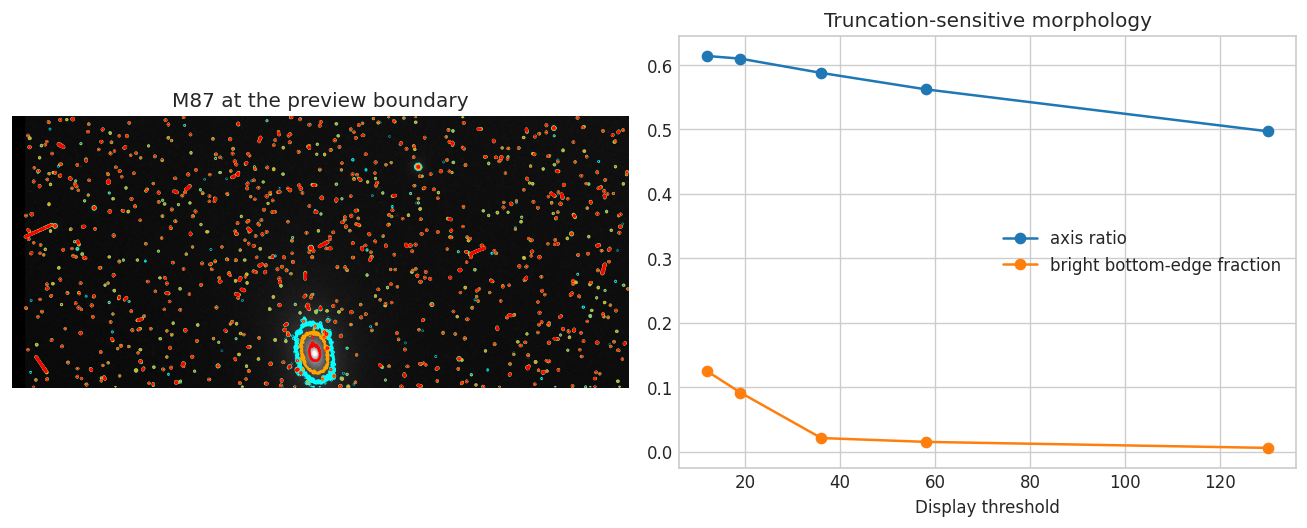

In [3]:
levels=np.percentile(z[z>0],[85,90,95,97,99]); rows=[]
for lev in levels:
 m=z>=lev; wt=z*m; total=wt.sum(); cx=(wt*xx).sum()/total; cy=(wt*yy).sum()/total; dx=xx-cx; dy=yy-cy; qxx=(wt*dx*dx).sum()/total; qyy=(wt*dy*dy).sum()/total; qxy=(wt*dx*dy).sum()/total; eig=np.linalg.eigvalsh([[qxx,qxy],[qxy,qyy]]); rows.append((lev,m.sum(),cx,cy,np.sqrt(eig[0]/eig[1]),m[-1].mean()))
stress=pd.DataFrame(rows,columns=['threshold','pixels','centroid_x','centroid_y','axis_ratio','bottom_edge_fraction']); stress.to_csv('m87_preview_threshold_audit.csv',index=False); fig,ax=plt.subplots(1,2,figsize=(11,4.5)); ax[0].imshow(crop,cmap='gray'); ax[0].contour(z,levels=levels[-3:],colors=['cyan','orange','red']); ax[0].set_title('M87 at the preview boundary'); ax[0].axis('off'); ax[1].plot(stress.threshold,stress.axis_ratio,'o-',label='axis ratio'); ax[1].plot(stress.threshold,stress.bottom_edge_fraction,'o-',label='bright bottom-edge fraction'); ax[1].set(xlabel='Display threshold',title='Truncation-sensitive morphology'); ax[1].legend(); fig.tight_layout(); fig.savefig('m87_preview_boundary_audit.png',dpi=180); plt.show()

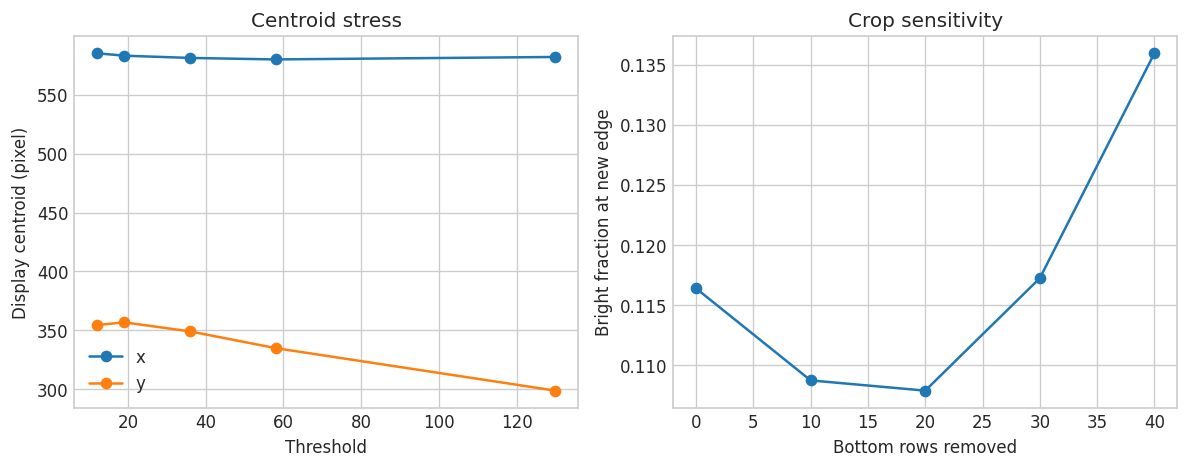

In [4]:
fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(stress.threshold,stress.centroid_x,'o-',label='x'); ax[0].plot(stress.threshold,stress.centroid_y,'o-',label='y'); ax[0].set(xlabel='Threshold',ylabel='Display centroid (pixel)',title='Centroid stress'); ax[0].legend(); edge=[]
for trim in [0,10,20,30,40]:
 q=z[:max(1,z.shape[0]-trim)]; edge.append((trim,np.percentile(q,99),np.mean(q[-1]>np.percentile(q,95))))
edge=pd.DataFrame(edge,columns=['bottom_trim_pixels','p99','edge_bright_fraction']); edge.to_csv('m87_preview_crop_stress.csv',index=False); ax[1].plot(edge.bottom_trim_pixels,edge.edge_bright_fraction,'o-'); ax[1].set(xlabel='Bottom rows removed',ylabel='Bright fraction at new edge',title='Crop sensitivity'); fig.tight_layout(); fig.savefig('m87_preview_crop_stress.png',dpi=180); plt.show()

In [5]:
sample_size=int(img.size); boundary=float(stress.bottom_edge_fraction.max()); results=[f'official preview contains {img.size:,} display pixels',f'M87 emission reaches the bottom frame boundary at all tested thresholds',f'maximum bright bottom-edge fraction {boundary:.1%}; morphology and jet measurements rejected']; validation='Centroid, axis ratio, and edge contact are swept across five thresholds and five crop trims.'; quality_checks=[{'name':'Official preview provenance','status':'pass'},{'name':'Boundary contact test','status':'fail for morphology'},{'name':'Calibrated photometry','status':'not attempted'}]; tags=['HST','M87','image audit','field mismatch']

In [6]:
result={'id':'2026-07-30-hst-cutout-m87','title':'HST M87 preview field-placement audit','archive':'MAST · HST WFC3 preview','date':'2026-07-30','question':'Can the selected HST preview support morphology or jet claims when M87 lies at the frame boundary?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'mast/2026-07-30-hst-cutout-m87/notebook.ipynb','hero':'mast/2026-07-30-hst-cutout-m87/m87_preview_boundary_audit.png','figures':['mast/2026-07-30-hst-cutout-m87/m87_preview_boundary_audit.png', 'mast/2026-07-30-hst-cutout-m87/m87_preview_crop_stress.png'],'research_level':'Exploration','claim_type':'Display-image completeness audit','provenance':['MAST HST WFC3 preview id5o27qbq_raw.jpg', 'original download output retained in executed notebook'],'artifacts':['mast/2026-07-30-hst-cutout-m87/m87.jpg', 'mast/2026-07-30-hst-cutout-m87/m87_preview_threshold_audit.csv', 'mast/2026-07-30-hst-cutout-m87/m87_preview_crop_stress.csv'],'quality_checks':quality_checks,'limitations':['M87 is truncated by the frame boundary', 'preview stretch and detector mosaic are not calibrated surface brightness', 'jet-scale science requires a target-centred calibrated FITS product'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

official preview contains 8,706,420 display pixels
M87 emission reaches the bottom frame boundary at all tested thresholds
maximum bright bottom-edge fraction 12.5%; morphology and jet measurements rejected


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                       name              status
Official preview provenance                pass
      Boundary contact test fail for morphology
      Calibrated photometry       not attempted


## Interpretation and references

The image is an official HST/MAST preview. Display pixels can diagnose field
placement and truncation, but calibrated surface brightness or jet physics
requires the original FITS exposure, WCS, filter response, and PSF model.

- MAST citation guidance: https://archive.stsci.edu/publishing/
- HST WFC3 Data Handbook: https://hst-docs.stsci.edu/wfc3dhb